In [54]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
# Data Loading
data = r'C:\Users\uzair\Downloads\Spotify\dataset.csv'
pd.set_option("display.max_columns", None)
df = pd.read_csv(data)
df.head() #114000 rows × 21 columns

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [56]:
# data exploration
print('Shape:' , df.shape)
print('Columns: ', df.columns)
print('Duplicated Track: ',df.duplicated(subset=['track_id']).sum())
print('x-----------------------------------------------------------------------------------------------x')
df.info()
df.describe()

Shape: (114000, 21)
Columns:  Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')
Duplicated Track:  24259
x-----------------------------------------------------------------------------------------------x
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms   

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [57]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [58]:
# Data Cleaning
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df = df.drop_duplicates(subset=['track_id'])
df = df.dropna(subset=['popularity','danceability','energy','valence'])
dfClean = df.copy()

In [59]:
hitThreshold = dfClean['popularity'].quantile(0.80)
dfClean['isHit'] = dfClean['popularity'] >= hitThreshold
dfClean[['track_name','artists','popularity','isHit']].head()

,track_name,artists,popularity,isHit
0,Comedy,Gen Hoshino,73,True
1,Ghost - Acoustic,Ben Woodward,55,True
2,To Begin Again,Ingrid Michaelson;ZAYN,57,True
3,Can't Help Falling In Love,Kina Grannis,71,True
4,Hold On,Chord Overstreet,82,True


In [60]:
counts = dfClean.groupby('artists')['track_id'].transform('count')

dfClean['artist_category'] = np.where(
    (counts > 0) & (counts < 10),
    'Emerging',
    'Established'
)

In [61]:
dfClean

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,isHit,artist_category
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,True,Emerging
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,True,Emerging
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,True,Emerging
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,True,Established
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,True,Established
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,False,Emerging
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,False,Emerging
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,False,Established
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,False,Established


In [62]:
audioFeatures = [
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'instrumentalness',
    'liveness',
    'speechiness'
]
hitDNA = dfClean.groupby('isHit')[audioFeatures].mean()

hitDNA

,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness
isHit,,,,,,,
False,0.556793,0.637224,0.472331,0.334877,0.189226,0.225623,0.090019
True,0.582484,0.623996,0.458687,0.303377,0.113617,0.184247,0.077698


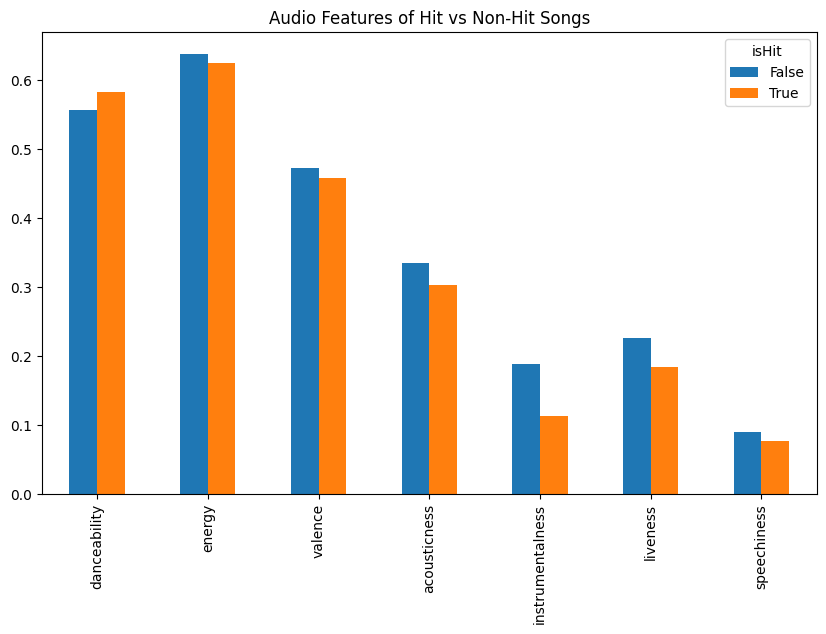

In [63]:
hitDNA.T.plot(kind='bar', figsize=(10,6))

plt.title("Audio Features of Hit vs Non-Hit Songs")
plt.show()

In [64]:
featureCorr = dfClean[audioFeatures + ['popularity']].corr()

featureCorr['popularity'].sort_values(ascending=False)

popularity          1.000000
danceability        0.064281
energy              0.013728
valence            -0.011526
liveness           -0.013844
acousticness       -0.038847
speechiness        -0.047081
instrumentalness   -0.127465
Name: popularity, dtype: float64

In [88]:
establishedArtists = dfClean[dfClean['artist_category'] == 'Established'].groupby('artists').agg(
        trackCount=('track_id','count'),
        avgPopularity=('popularity','mean'),
        avgDanceability=('danceability','mean'),
        avgEnergy=('energy','mean'),
        avgValence=('valence','mean')
    ).reset_index()

In [89]:
establishedArtists.head(4)

,artists,trackCount,avgPopularity,avgDanceability,avgEnergy,avgValence
0,"""Weird Al"" Yankovic",15,26.333333,0.657400,0.575000,0.736000
1,(Hed) P.E.,17,24.411765,0.612824,0.863765,0.515647
2,2 Brothers On The 4th Floor,21,23.809524,0.641333,0.881905,0.639810
3,25th Annual Putnam County Spelling Bee Origina...,14,29.357143,0.526429,0.325086,0.523857


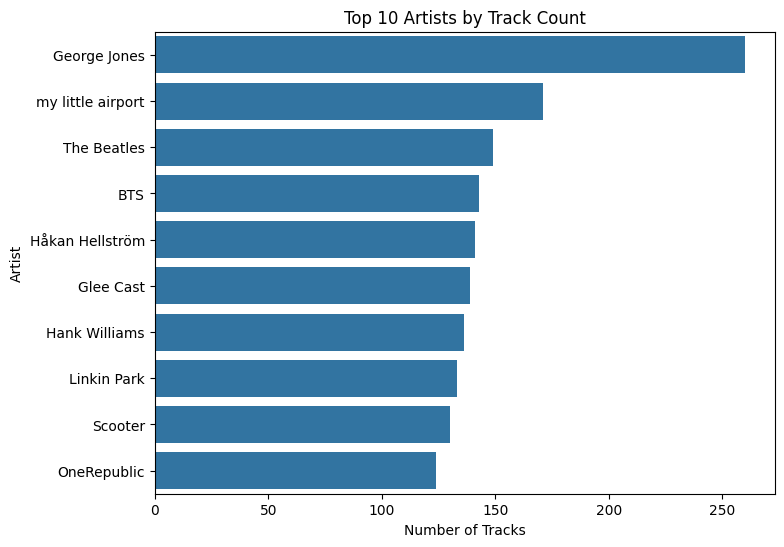

In [67]:
topEstablishedArtists = establishedArtists.sort_values(by='trackCount', ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=topEstablishedArtists, x='trackCount', y='artists')
plt.title('Top 10 Artists by Track Count')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.show()

In [91]:
emergingArtists = dfClean[dfClean['artist_category']=='Emerging'].groupby('artists').agg(
        trackCount=('track_id','count'),
        avgPopularity=('popularity','mean'),
        avgDanceability=('danceability','mean'),
        avgEnergy=('energy','mean'),
        avgValence=('valence','mean')
).reset_index()

In [95]:
emergingArtists.sort_values(by='avgPopularity',ascending=False).head(10)

,artists,trackCount,avgPopularity,avgDanceability,avgEnergy,avgValence
22837,Sam Smith;Kim Petras,1,100.0,0.714000,0.472000,0.238
3447,Bizarrap;Quevedo,1,99.0,0.621000,0.782000,0.550
16518,Manuel Turizo,1,98.0,0.835000,0.679000,0.850
2718,Bad Bunny;Chencho Corleone,1,97.0,0.911000,0.712000,0.425
2716,Bad Bunny;Bomba Estéreo,1,95.0,0.647000,0.686000,0.268
12854,Joji,1,94.0,0.440000,0.317000,0.268
3275,Beyoncé,1,93.0,0.780000,0.689000,0.642
10909,Harry Styles,3,92.0,0.529333,0.759333,0.627
21622,Rema;Selena Gomez,1,92.0,0.801000,0.806000,0.802
21447,Rauw Alejandro;Lyanno;Brray,1,91.0,0.834000,0.828000,0.580


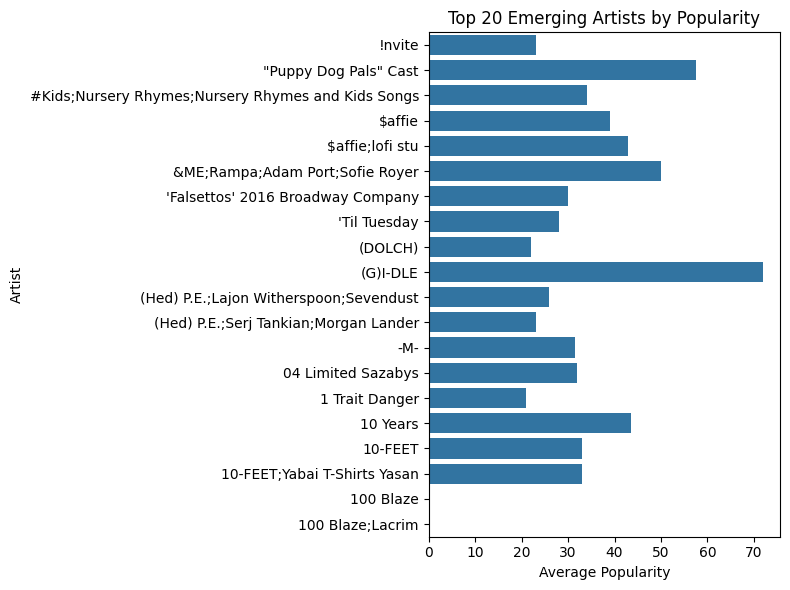

In [69]:
topEmerging = emergingArtists.head(20)

plt.figure(figsize=(8, 6))

sns.barplot(data=topEmerging, x='avgPopularity', y='artists')

plt.title('Top 20 Emerging Artists by Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

In [70]:
genreStats = dfClean.groupby('track_genre').agg(
    avgPopularity=('popularity','mean'),
    volume=('track_id','count')
).reset_index()

genreStats.head()

,track_genre,avgPopularity,volume
0,acoustic,42.483000,1000
1,afrobeat,24.407407,999
2,alt-rock,33.896897,999
3,alternative,22.218673,407
4,ambient,44.208208,999


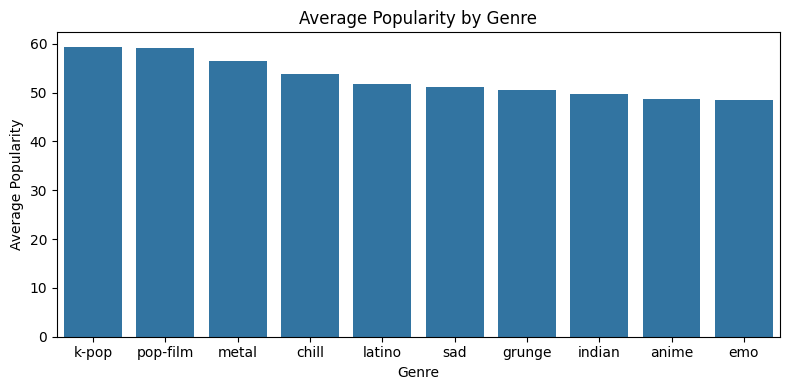

In [71]:
genreStatsSorted = genreStats.sort_values(by='avgPopularity', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=genreStatsSorted, x='track_genre', y='avgPopularity', ax=ax)
ax.set_title('Average Popularity by Genre')
ax.set_ylabel('Average Popularity')
ax.set_xlabel('Genre')
plt.tight_layout()
plt.show()

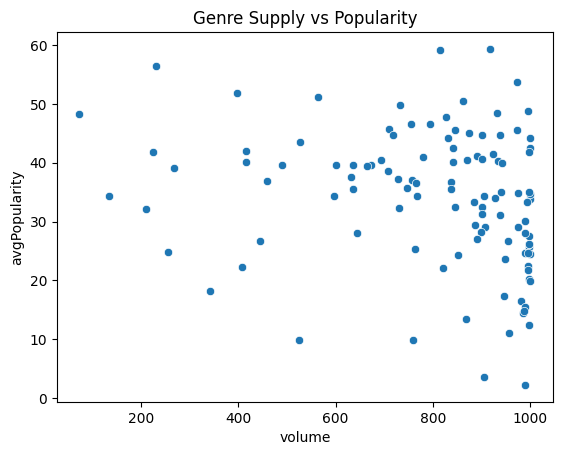

In [72]:
sns.scatterplot(
data=genreStats,
x='volume',
y='avgPopularity'
)

plt.title("Genre Supply vs Popularity")
plt.show()


In [73]:
genreHitRate = dfClean.groupby('track_genre')['isHit'].mean().reset_index()

genreHitRate.rename(columns={'isHit':'hitRate'}, inplace=True)

genreHitRate.sort_values('hitRate', ascending=False).head(10)

,track_genre,hitRate
81,pop-film,0.942331
15,chill,0.729424
71,metal,0.702586
65,k-pop,0.690294
51,hip-hop,0.648456
44,grunge,0.599768
80,pop,0.572115
30,edm,0.547550
94,sad,0.546099
11,british,0.535556


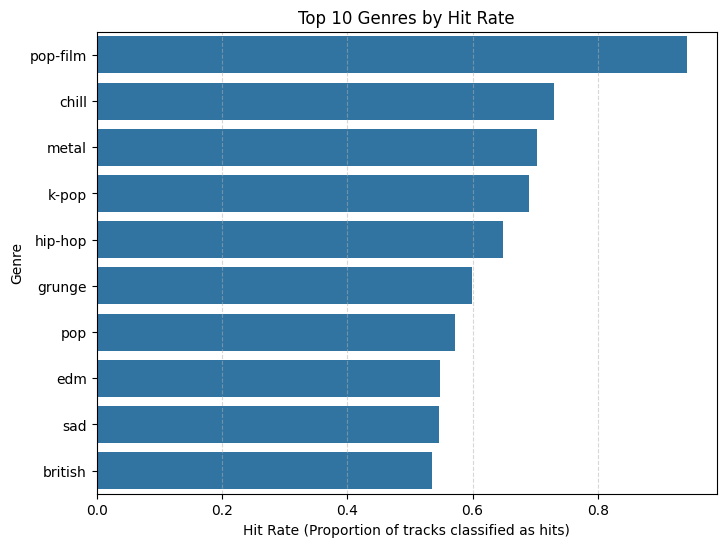

In [74]:
topHitGenres = genreHitRate.sort_values('hitRate', ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=topHitGenres, x='hitRate', y='track_genre')
plt.title('Top 10 Genres by Hit Rate')
plt.xlabel('Hit Rate (Proportion of tracks classified as hits)')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [75]:
dfClean.to_excel("tracks.xlsx", index=False)

In [90]:
establishedArtists.to_excel("artists.xlsx", index=False)

In [92]:
emergingArtists.to_excel("emerging_artists.xlsx", index=False)

In [78]:
genreStats.to_excel("genre_stats.xlsx", index=False)

In [79]:
genreHitRate.to_excel("genre_hit_rate.xlsx", index=False)

In [86]:
dfClean[dfClean["isHit"] == False].groupby('album_name').agg(
    albumName = ('album_name','count')
).sort_values(by='albumName', ascending=False)

,albumName
album_name,
The Complete Hank Williams,110
Mozart: A Night of Classics,75
Alternative Christmas 2022,73
Mozart - All Day Classics,68
Hans Zimmer: Epic Scores,68
...,...
"!!!"" Baby Sleep Aid Rain Sounds ""!!!",1
"! !""#Reboot#""! !",1
! ! % > (( Shelter )) < % ! !,1


In [83]:
dfClean[dfClean["isHit"]].groupby("album_name").size().sort_values(ascending=False)

album_name
Hamilton (Original Broadway Cast Recording)         36
Greatest Hits                                       25
Proof                                               24
Moosetape                                           23
Love Yourself 結 'Answer'                            23
                                                    ..
$tars and I feel alone                               1
&                                                    1
'BLACKPINK 2018 TOUR 'IN YOUR AREA' SEOUL - Live     1
黑暗的盡頭                                                1
당신이 잠든 사이에 Pt. 1 Original Television Soundtrack      1
Length: 12973, dtype: int64